In [4]:
import os
from pathlib import Path
from datetime import datetime

# lists files in the current directory (Jupyter cell)


def _human_size(n):
    if n is None:
        return ""
    n = float(n)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f}{unit}"
        n /= 1024
    return f"{n:.1f}PB"


def list_files(path=".", recursive=False, show_hidden=False):
    p = Path(path)
    entries = p.rglob("*") if recursive else p.iterdir()
    rows = []
    for e in entries:
        name = str(e.relative_to(p)) if recursive else e.name
        if not show_hidden and name.startswith("."):
            continue
        try:
            st = e.stat()
            size = st.st_size
            mtime = datetime.fromtimestamp(st.st_mtime).strftime("%Y-%m-%d %H:%M:%S")
        except Exception:
            size = None
            mtime = ""
        kind = "dir" if e.is_dir() else "symlink" if e.is_symlink() else "file"
        rows.append((name, kind, _human_size(size), size, mtime))
    rows.sort(key=lambda r: r[0].lower())
    print(f"{'Name':60} {'Type':6} {'Size':10} {'Bytes':12} {'Modified':19}")
    print("-" * 110)
    for name, kind, hsz, bytesize, mtime in rows:
        print(f"{name:60.60} {kind:6} {hsz:10} {str(bytesize):12} {mtime}")
    return rows


# Example usage: change flags as needed
files = list_files(path="IVs Bilayer B parallel", recursive=False, show_hidden=False)

Name                                                         Type   Size       Bytes        Modified           
--------------------------------------------------------------------------------------------------------------
IVs _1.821E+0 K_-1.052E-1T_-9.960E-2T_0_1.dat                file   227.0KB    232414       2026-01-31 22:04:31
IVs _1.821E+0 K_-1.302E-3T_-5.200E-5T_0_1.dat                file   227.0KB    232426       2026-01-31 22:15:56
IVs _1.821E+0 K_-1.540E-1T_-1.495E-1T_0_1.dat                file   227.0KB    232445       2026-01-31 21:58:47
IVs _1.821E+0 K_-2.046E-1T_-1.996E-1T_0_1.dat                file   227.0KB    232422       2026-01-31 21:53:04
IVs _1.821E+0 K_-5.436E-2T_-4.959E-2T_0_1.dat                file   227.4KB    232873       2026-01-31 22:10:15
IVs _1.821E+0 K_1.032E-1T_9.965E-2T_0_1.dat                  file   227.2KB    232611       2026-01-31 22:27:22
IVs _1.821E+0 K_1.525E-1T_1.496E-1T_0_1.dat                  file   227.0KB    232433       2026-01-31 22

In [10]:
import superconductivity.api as sc

In [45]:
import numpy as np

MAG = []
currents = []
voltages = []
diff_res = []
for file in files:
    name = file[0]
    fields = name.split("_")

    up = False
    if fields[-1][0] == "2":
        up = True
        mag1 = float(fields[2][:-1])
        mag2 = float(fields[3][:-1])
        mag = np.mean([mag1, mag2])

        data = np.genfromtxt(f"IVs Bilayer B parallel/{name}", skip_header=1)
        diff_re = data[:, 0]
        current = data[:, 2]
        voltage = data[:, 4]

        currents.append(current)
        voltages.append(voltage)
        diff_res.append(diff_re)
        MAG.append(mag)

In [ ]:
def bin_z_over_y(y: np.ndarray, z: np.ndarray, y_binned: np.ndarray):
    """
    Bin z-values over y-values using predefined bins.
    If a bin receives no data, fill it from the previous valid bin above (top-down fill).

    Parameters
    ----------
    y : np.ndarray
        Y-values to be binned.
    z : np.ndarray
        Corresponding Z-values (2D array with shape (N, M)).
    y_binned : np.ndarray
        Bin edges for y-values.

    Returns
    -------
    tuple
        Binned z-values (2D), and count of points in each bin.
    """
    number_of_bins = len(y_binned)
    counter = np.zeros(number_of_bins, dtype=int)
    result = np.zeros((number_of_bins, z.shape[1]), dtype=float)

    # Assign y-values to bins
    dig = np.digitize(y, bins=y_binned) - 1
    valid_indices = (dig >= 0) & (dig < number_of_bins)

    # Count entries and sum z-values into bins
    np.add.at(counter, dig[valid_indices], 1)
    np.add.at(result, dig[valid_indices], z[valid_indices])

    # Average values where data exists
    with np.errstate(invalid="ignore"):  # Suppress divide-by-zero warnings
        result[counter > 0] /= counter[counter > 0, None]
        result[counter == 0] = np.nan  # Mark empty bins as NaN

    # Top-down fill: fill missing rows from previous valid row above
    last_valid = None
    for i in range(number_of_bins):
        if counter[i] > 0:
            last_valid = result[i].copy()
        elif last_valid is not None:
            result[i] = last_valid

    return result, counter

In [ ]:
I_A = np.linspace(-0.003, 0.003, 1001)
B_T_temp = np.zeros(len(MAG))
V_V_temp = np.zeros((len(MAG), len(I_A)))
dR_temp = np.zeros((len(MAG), len(I_A)))

for i, mag in enumerate(MAG):
    B_T_temp[i] = mag
    V_V_temp[i, :] = sc.bin_y_over_x(currents[i], voltages[i], I_A)
    dR_temp[i, :] = sc.bin_y_over_x(currents[i], diff_res[i], I_A)

B_T = np.linspace(-7, 7, 211)

V_V, _ = bin_z_over_y(B_T_temp, V_V_temp, B_T)
dR, _ = bin_z_over_y(B_T_temp, dR_temp, B_T)

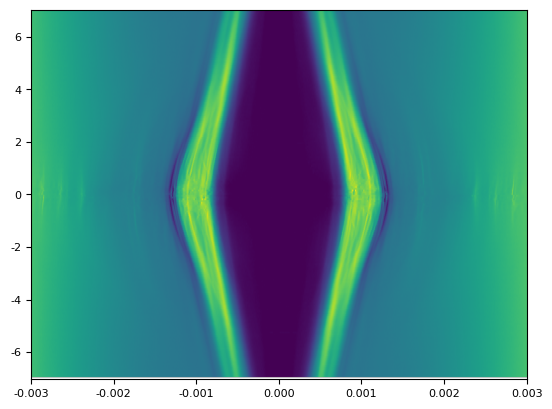

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(dR, origin='lower', aspect='auto', extent=sc.get_ext(I_A, B_T))